In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [216]:
data=pd.read_csv("global_earthquakes.csv")
# data
# data.columns
X = data[[
    "latitude",
    "longitude",
    "depth",
    "gap",
    "dmin",
    "rms",
    "horizontalError",
    "depthError",
    "magError",
    "magNst"
]]

X = X.fillna(X.median())
y=data["mag"]
# X
# check null values
X.isnull().sum()

,0
latitude,0
longitude,0
depth,0
gap,0
dmin,0
rms,0
horizontalError,0
depthError,0
magError,0
magNst,0


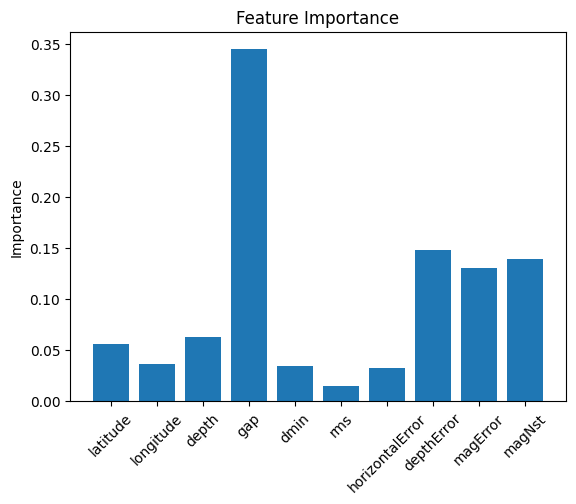

In [217]:
importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [218]:
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# Scaling data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
# train model
# model=LinearRegression()
model=xgb.XGBRegressor(n_estimators=100,random_state=42)
# model=RandomForestRegressor(n_estimators=100,random_state=42
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [219]:
# check performance of model
from sklearn.metrics import mean_squared_error,r2_score
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mse:", mse)
print("r2 score :",r2)

mse: 0.03330551662805121
r2 score : 0.7508998781096087


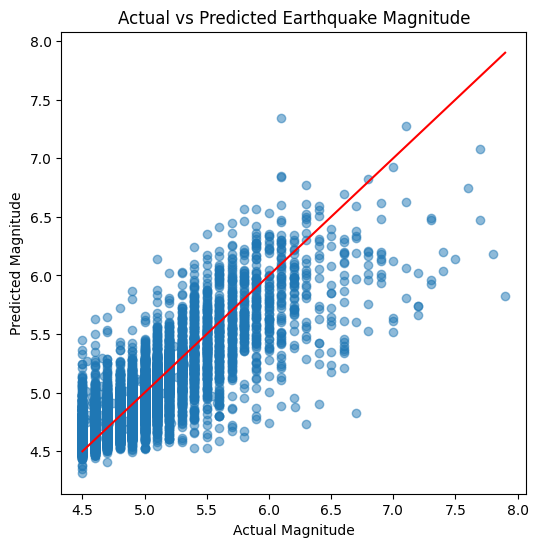

In [220]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Predicted Earthquake Magnitude")
plt.show()

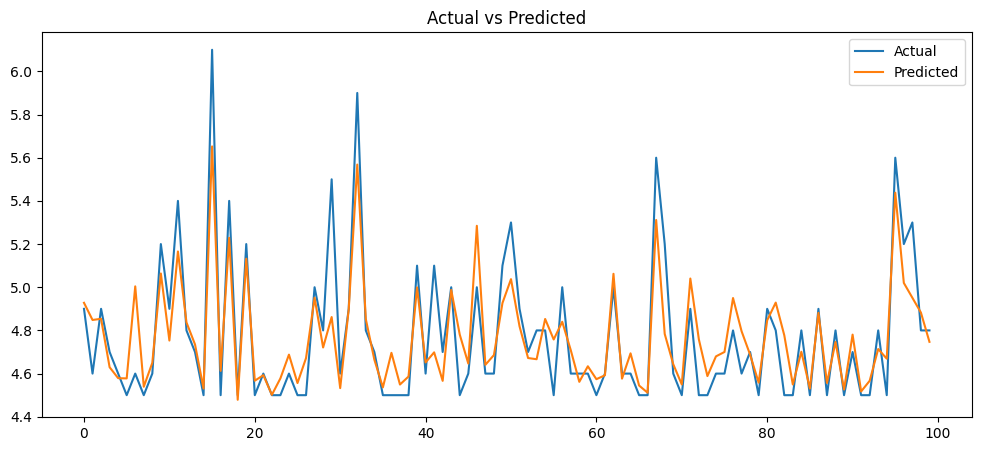

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

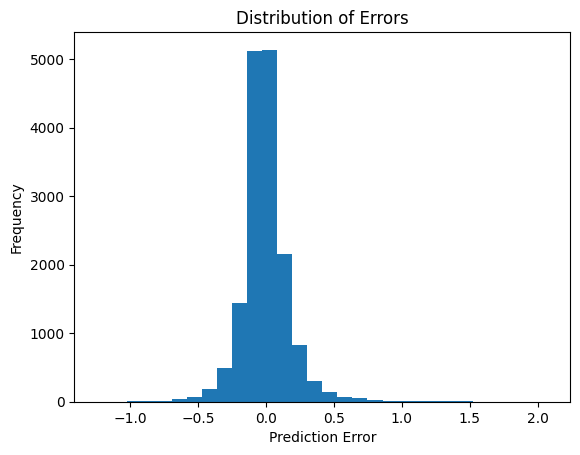

In [222]:
import matplotlib.pyplot as plt

errors = y_test - y_pred

plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Errors")
plt.show()